<a href="https://colab.research.google.com/github/scudilio/FIAP_MBA-Feature_Engineering/blob/main/Aula1_preprocessing_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Técnicas de Pré-processamento de Dados para Machine Learning

**Autor:** Material Didático - MBA Data Science FIAP

Este notebook apresenta as principais técnicas de pré-processamento de dados, fundamentais para preparar features antes de alimentar modelos de Machine Learning.

## Conteúdo

### Escalonamento de Variáveis Numéricas
1. **StandardScaler** - Padronização (z-score)
2. **MinMaxScaler** - Normalização min-max
3. **RobustScaler** - Escalonamento robusto a outliers

### Codificação de Variáveis Categóricas
4. **Label Encoding** - Codificação ordinal
5. **One-Hot Encoding** - Codificação binária
6. **Count/Frequency Encoding** - Codificação por frequência
7. **Rare Label Encoding** - Tratamento de categorias raras
8. **Target Encoding** - Codificação baseada no target

### Conceito Crítico
9. **Target Leakage** - Vazamento de informação do target

---

## Setup e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [18]:
# Carregamento do dataset
url = 'https://raw.githubusercontent.com/scudilio/Churn_model/refs/heads/master/dataset/Churn_Modelling.csv'
df1 = pd.read_csv(url)

print(f"Shape do dataset: {df.shape}")
print(f"\nPrimeiras linhas:")
df.head()

Shape do dataset: (10000, 11)

Primeiras linhas:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.0000,1,1,1,101348.8800,1
1,608,Spain,Female,41,1,83807.8600,1,0,1,112542.5800,0
2,502,France,Female,42,8,159660.8000,3,1,0,113931.5700,1
3,699,France,Female,39,1,0.0000,2,0,0,93826.6300,0
4,850,Spain,Female,43,2,125510.8200,1,1,1,79084.1000,0


In [19]:
# Análise inicial da estrutura
print("Informações do Dataset:")
print("=" * 50)
df1.info()

Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [20]:
# Estatísticas descritivas das variáveis numéricas
print("Estatísticas Descritivas:")
df1.describe()

Estatísticas Descritivas:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,5000.5000,15690940.5694,650.5288,38.9218,5.0128,76485.8893,1.5302,0.7055,0.5151,100090.2399,0.2037
std,2886.8957,71936.1861,96.6533,10.4878,2.8922,62397.4052,0.5817,0.4558,0.4998,57510.4928,0.4028
min,1.0000,15565701.0000,350.0000,18.0000,0.0000,0.0000,1.0000,0.0000,0.0000,11.5800,0.0000
25%,2500.7500,15628528.2500,584.0000,32.0000,3.0000,0.0000,1.0000,0.0000,0.0000,51002.1100,0.0000
50%,5000.5000,15690738.0000,652.0000,37.0000,5.0000,97198.5400,1.0000,1.0000,1.0000,100193.9150,0.0000
75%,7500.2500,15753233.7500,718.0000,44.0000,7.0000,127644.2400,2.0000,1.0000,1.0000,149388.2475,0.0000
max,10000.0000,15815690.0000,850.0000,92.0000,10.0000,250898.0900,4.0000,1.0000,1.0000,199992.4800,1.0000


In [21]:
# Identificação dos tipos de variáveis
# Removendo colunas de identificação que não serão usadas como features
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df = df1.drop(columns=cols_to_drop)
# Variáveis numéricas contínuas
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Variáveis categóricas
categorical_cols = ['Geography', 'Gender']

# Variáveis binárias (já codificadas)
binary_cols = ['NumOfProducts', 'HasCrCard', 'IsActiveMember']

# Target
target = 'Exited'

print(f"Variáveis numéricas: {numeric_cols}")
print(f"Variáveis categóricas: {categorical_cols}")
print(f"Variáveis binárias: {binary_cols}")
print(f"Target: {target}")

Variáveis numéricas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
Variáveis categóricas: ['Geography', 'Gender']
Variáveis binárias: ['NumOfProducts', 'HasCrCard', 'IsActiveMember']
Target: Exited


In [12]:
##outra maneira de fazer a identificacao da coluna de maneira automatica
# Exemplo: df já carregado
# df = pd.read_csv(...)

# Colunas de identificação (heurística comum)
id_cols = [c for c in df.columns if 'id' in c.lower() or 'row' in c.lower()]

# Target (se já souber o nome)
target = 'Exited'

# Remove id e target do processo
features = df.drop(columns=id_cols + [target])

# Numéricas
numeric_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categóricas
categorical_cols = features.select_dtypes(include=['object', 'category']).columns.tolist()

print("IDs:", id_cols)
print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)
print("Target:", target)


IDs: []
Numéricas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categóricas: ['Geography', 'Gender']
Target: Exited


In [13]:
# Distribuição do target
print("Distribuição do Target (Exited):")
print(df[target].value_counts())
print(f"\nProporção de Churn: {df[target].mean():.2%}")

Distribuição do Target (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64

Proporção de Churn: 20.37%


# PARTE 1: CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS

Modelos de ML trabalham com números. Precisamos converter variáveis categóricas (texto) em representações numéricas.

---

## A. Label Encoding (Codificação Ordinal)

### Conceito:
Atribui um número inteiro único para cada categoria.

### Exemplo:
```
France  → 0
Germany → 1
Spain   → 2
```

### Vantagens:
- Simples e rápido
- Não aumenta dimensionalidade

### Desvantagens:
- **Impõe ordem artificial:** o modelo pode interpretar que Germany (1) > France (0)
- **Inadequado para variáveis nominais** (sem ordem natural)

### Quando usar:
- Variáveis **ordinais** (com ordem natural): baixo < médio < alto, ruim < bom < ótimo
- Árvores de decisão (conseguem lidar com a "ordem artificial")
- Target encoding inicial (variável target)

In [14]:
# Análise das variáveis categóricas
print("=== Análise das Variáveis Categóricas ===")

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

=== Análise das Variáveis Categóricas ===

Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [15]:
# Label Encoding usando sklearn
print("=== Label Encoding ===")

df_label = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_label[f'{col}_le'] = le.fit_transform(df_label[col])

    print(f"\n{col}:")
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  Mapeamento: {mapping}")

# Verificando o resultado
print("\n\nResultado:")
df_label[categorical_cols + [f'{col}_le' for col in categorical_cols]].head(10)

=== Label Encoding ===

Geography:
  Mapeamento: {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}

Gender:
  Mapeamento: {'Female': np.int64(0), 'Male': np.int64(1)}


Resultado:


,Geography,Gender,Geography_le,Gender_le
0,France,Female,0,0
1,Spain,Female,2,0
2,France,Female,0,0
3,France,Female,0,0
4,Spain,Female,2,0
5,Spain,Male,2,1
6,France,Male,0,1
7,Germany,Female,1,0
8,France,Male,0,1
9,France,Male,0,1


In [25]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.0000,1,1,1,101348.8800,1
1,608,Spain,Female,41,1,83807.8600,1,0,1,112542.5800,0
2,502,France,Female,42,8,159660.8000,3,1,0,113931.5700,1
3,699,France,Female,39,1,0.0000,2,0,0,93826.6300,0
4,850,Spain,Female,43,2,125510.8200,1,1,1,79084.1000,0


# O PROBLEMA do Label Encoding para variáveis nominais
print("=== ⚠️ PROBLEMA: Ordem Artificial ===")
print("""
Com Label Encoding, Geography ficou:
  France  = 0
  Germany = 1
  Spain   = 2

Um modelo linear pode interpretar que:
  - Spain (2) tem 'maior valor' que Germany (1)
  - A distância France→Germany = distância Germany→Spain

Isso não faz sentido para variáveis nominais (sem ordem)!

Para variáveis ORDINAIS (ex: escolaridade), Label Encoding é adequado:
  Fundamental = 0 < Médio = 1 < Superior = 2 < Pós-graduação = 3
""")

---

## B5. One-Hot Encoding (Codificação Binária / Dummy Variables)

### Conceito:
Cria uma coluna binária (0/1) para cada categoria.

### Exemplo:
```
Geography    →  Geography_France  Geography_Germany  Geography_Spain
France           1                 0                  0
Germany          0                 1                  0
Spain            0                 0                  1
```

### Vantagens:
- Não impõe ordem artificial
- Adequado para variáveis nominais

### Desvantagens:
- **Aumenta dimensionalidade:** k categorias → k colunas (ou k-1 com drop_first)
- **Dummy Variable Trap:** para modelos lineares, usar k-1 colunas (drop_first=True)
- **Problema com alta cardinalidade:** variável com 1000 categorias → 1000 colunas

### Quando usar:
- Variáveis nominais com **baixa cardinalidade** (poucas categorias)
- Regressão Linear, Regressão Logística, SVM, Redes Neurais

In [16]:
# One-Hot Encoding usando pandas (get_dummies)
print("=== One-Hot Encoding com pandas ===")

df_onehot = pd.get_dummies(df[categorical_cols], prefix=categorical_cols)

print(f"\nColunas originais: {categorical_cols}")
print(f"Colunas após One-Hot: {list(df_onehot.columns)}")
print(f"\nDimensionalidade: {len(categorical_cols)} → {len(df_onehot.columns)}")

df_onehot.head(10)

=== One-Hot Encoding com pandas ===

Colunas originais: ['Geography', 'Gender']
Colunas após One-Hot: ['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']

Dimensionalidade: 2 → 5


,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,True,False,False,True,False
1,False,False,True,True,False
2,True,False,False,True,False
3,True,False,False,True,False
4,False,False,True,True,False
5,False,False,True,False,True
6,True,False,False,False,True
7,False,True,False,True,False
8,True,False,False,False,True
9,True,False,False,False,True


In [22]:
# One-Hot Encoding com drop_first (evita Dummy Variable Trap)
print("=== One-Hot Encoding com drop_first=True ===")

df_onehot_drop = pd.get_dummies(df[categorical_cols], prefix=categorical_cols, drop_first=True)

print(f"\nColunas após One-Hot (drop_first): {list(df_onehot_drop.columns)}")
print(f"\nDimensionalidade: {len(categorical_cols)} → {len(df_onehot_drop.columns)}")

df_onehot_drop.head(10)

=== One-Hot Encoding com drop_first=True ===

Colunas após One-Hot (drop_first): ['Geography_Germany', 'Geography_Spain', 'Gender_Male']

Dimensionalidade: 2 → 3


,Geography_Germany,Geography_Spain,Gender_Male
0,False,False,False
1,False,True,False
2,False,False,False
3,False,False,False
4,False,True,False
5,False,True,True
6,False,False,True
7,True,False,False
8,False,False,True
9,False,False,True


In [23]:
# Explicação do Dummy Variable Trap
print("=== Dummy Variable Trap ===")
print("""
PROBLEMA: Se todas as colunas dummy estão presentes, existe multicolinearidade perfeita.

Com 3 países (France, Germany, Spain), se:
  - Geography_France = 0
  - Geography_Germany = 0
  Então SABEMOS que Geography_Spain = 1

A terceira coluna é redundante (pode ser calculada pelas outras).

SOLUÇÃO: drop_first=True remove uma categoria de referência.
  - France = 0, 0 (referência)
  - Germany = 1, 0
  - Spain = 0, 1

Para Regressão Linear/Logística: SEMPRE usar drop_first=True
Para Árvores/Random Forest: pode usar todas as colunas (não afeta)
""")

=== Dummy Variable Trap ===

PROBLEMA: Se todas as colunas dummy estão presentes, existe multicolinearidade perfeita.

Com 3 países (France, Germany, Spain), se:
  - Geography_France = 0
  - Geography_Germany = 0
  Então SABEMOS que Geography_Spain = 1

A terceira coluna é redundante (pode ser calculada pelas outras).

SOLUÇÃO: drop_first=True remove uma categoria de referência.
  - France = 0, 0 (referência)
  - Germany = 1, 0
  - Spain = 0, 1

Para Regressão Linear/Logística: SEMPRE usar drop_first=True
Para Árvores/Random Forest: pode usar todas as colunas (não afeta)



1️⃣ Equivalente direto ao get_dummies(drop_first=True) com scikit-learn

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(
    drop='first',          # equivalente ao drop_first=True
    sparse_output=False,   # retorna array denso (igual DataFrame)
    handle_unknown='ignore'
)

# Fit + transform apenas nas categóricas
ohe_array = ohe.fit_transform(df[categorical_cols])

# Recuperar nomes das colunas
ohe_cols = ohe.get_feature_names_out(categorical_cols)

# Converter para DataFrame
df_onehot_sklearn = pd.DataFrame(
    ohe_array,
    columns=ohe_cols,
    index=df.index
)

print("=== One-Hot Encoding com scikit-learn (drop='first') ===")
print(f"Colunas após One-Hot: {list(df_onehot_sklearn.columns)}")
print(f"Dimensionalidade: {len(categorical_cols)} → {len(df_onehot_sklearn.columns)}")

df_onehot_sklearn.head(10)


In [26]:
# Problema com alta cardinalidade (exemplo: Surname)
print("=== ⚠️ Problema: Alta Cardinalidade ===")

n_surnames = df1['Surname'].nunique()
print(f"\nNúmero de sobrenomes únicos: {n_surnames}")
print(f"\nSe aplicarmos One-Hot Encoding em Surname:")
print(f"  - Criaríamos {n_surnames} novas colunas!")
print(f"  - Isso causaria:")
print(f"    • Explosão dimensional")
print(f"    • Overfitting")
print(f"    • Lentidão no treinamento")
print(f"\nPara alta cardinalidade, usar: Count/Frequency Encoding, Target Encoding, etc.")

=== ⚠️ Problema: Alta Cardinalidade ===

Número de sobrenomes únicos: 2932

Se aplicarmos One-Hot Encoding em Surname:
  - Criaríamos 2932 novas colunas!
  - Isso causaria:
    • Explosão dimensional
    • Overfitting
    • Lentidão no treinamento

Para alta cardinalidade, usar: Count/Frequency Encoding, Target Encoding, etc.


---

## C. Count / Frequency Encoding (Codificação por Frequência)

### Conceito:
Substitui cada categoria pela sua **contagem** ou **frequência relativa** no dataset.

### Exemplo:
```
Categoria    Count   Frequency
France       5014    0.5014
Germany      2509    0.2509
Spain        2477    0.2477

France → 5014 (count) ou 0.5014 (frequency)
```

### Vantagens:
- Não aumenta dimensionalidade
- Funciona bem com alta cardinalidade
- Captura popularidade/frequência

### Desvantagens:
- Perde informação específica da categoria
- Categorias com mesma frequência terão mesmo valor

### Quando usar:
- Alta cardinalidade
- Quando a frequência é informativa para o problema

In [ ]:
# Count Encoding
print("=== Count Encoding ===")

df_count = df.copy()

for col in categorical_cols:
    count_map = df[col].value_counts().to_dict()
    df_count[f'{col}_count'] = df_count[col].map(count_map)

    print(f"\n{col} - Count Mapping:")
    print(count_map)

print("\n\nResultado:")
df_count[categorical_cols + [f'{col}_count' for col in categorical_cols]].head(10)

In [ ]:
# Frequency Encoding (proporção)
print("=== Frequency Encoding ===")

df_freq = df.copy()

for col in categorical_cols:
    freq_map = (df[col].value_counts() / len(df)).to_dict()
    df_freq[f'{col}_freq'] = df_freq[col].map(freq_map)

    print(f"\n{col} - Frequency Mapping:")
    for k, v in freq_map.items():
        print(f"  {k}: {v:.4f}")

print("\n\nResultado:")
df_freq[categorical_cols + [f'{col}_freq' for col in categorical_cols]].head(10)

In [ ]:
# Aplicando em variável de alta cardinalidade (Surname)
print("=== Frequency Encoding para Alta Cardinalidade (Surname) ===")

surname_freq = (df['Surname'].value_counts() / len(df)).to_dict()
df_freq['Surname_freq'] = df['Surname'].map(surname_freq)

print(f"\nTop 10 sobrenomes mais frequentes:")
top_surnames = df['Surname'].value_counts().head(10)
for name, count in top_surnames.items():
    print(f"  {name}: {count} ({count/len(df):.4f})")

print("\n\nExemplo do resultado:")
df_freq[['Surname', 'Surname_freq']].head(10)

---

## 7. Rare Label Encoding (Codificação de Categorias Raras)

### Conceito:
Agrupa categorias pouco frequentes em uma única categoria "Raro" ou "Outros".

### Por que usar:
- Categorias raras têm poucos exemplos para o modelo aprender
- Podem causar overfitting (modelo memoriza casos específicos)
- Reduz dimensionalidade após One-Hot Encoding
- Categorias novas no teste podem ser tratadas como "Raro"

### Estratégias:
1. **Threshold por frequência:** categorias com < X% são raras
2. **Threshold por contagem:** categorias com < N observações são raras
3. **Top K:** manter apenas as K categorias mais frequentes

In [27]:
# Análise de distribuição de frequência dos Sobrenomes
print("=== Distribuição de Frequência dos Sobrenomes ===")

surname_counts = df1['Surname'].value_counts()

print(f"\nTotal de sobrenomes únicos: {len(surname_counts)}")
print(f"\nDistribuição de contagens:")
print(surname_counts.describe())

# Quantos sobrenomes aparecem apenas 1, 2, 3 vezes?
print("\nFrequência de contagens:")
for n in range(1, 6):
    count = (surname_counts == n).sum()
    pct = count / len(surname_counts) * 100
    print(f"  Sobrenomes que aparecem {n}x: {count} ({pct:.1f}%)")

=== Distribuição de Frequência dos Sobrenomes ===

Total de sobrenomes únicos: 2932

Distribuição de contagens:
count   2932.0000
mean       3.4106
std        4.3552
min        1.0000
25%        1.0000
50%        1.0000
75%        4.0000
max       32.0000
Name: count, dtype: float64

Frequência de contagens:
  Sobrenomes que aparecem 1x: 1558 (53.1%)
  Sobrenomes que aparecem 2x: 354 (12.1%)
  Sobrenomes que aparecem 3x: 222 (7.6%)
  Sobrenomes que aparecem 4x: 177 (6.0%)
  Sobrenomes que aparecem 5x: 126 (4.3%)


In [28]:
# Rare Label Encoding - Método 1: Threshold por frequência
print("=== Rare Label Encoding (Threshold por Frequência) ===")

def rare_label_encoder(df, col, threshold=0.01):
    """
    Substitui categorias com frequência < threshold por 'Rare'

    Args:
        df: DataFrame
        col: nome da coluna
        threshold: frequência mínima (padrão 1%)
    """
    freq = df[col].value_counts() / len(df)
    rare_labels = freq[freq < threshold].index.tolist()

    result = df[col].apply(lambda x: 'Rare' if x in rare_labels else x)

    return result, len(rare_labels)

# Aplicando com threshold de 0.1% (cada sobrenome deve ter pelo menos 0.1% do dataset)
df_rare = df1.copy()
threshold = 0.001  # 0.1%

df_rare['Surname_rare'], n_rare = rare_label_encoder(df_rare, 'Surname', threshold)

print(f"\nThreshold: {threshold*100}% ({int(threshold*len(df))} observações mínimas)")
print(f"Sobrenomes classificados como 'Rare': {n_rare}")
print(f"\nCategorias restantes: {df_rare['Surname_rare'].nunique()}")
print(f"\nDistribuição após Rare Label Encoding:")
print(df_rare['Surname_rare'].value_counts().head(15))

=== Rare Label Encoding (Threshold por Frequência) ===

Threshold: 0.1% (10 observações mínimas)
Sobrenomes classificados como 'Rare': 2647

Categorias restantes: 286

Distribuição após Rare Label Encoding:
Surname_rare
Rare        5743
Smith         32
Martin        29
Scott         29
Walker        28
Brown         26
Genovese      25
Yeh           25
Shih          25
Wright        24
Maclean       24
Ma            23
White         23
Wilson        23
Fanucci       23
Name: count, dtype: int64


In [29]:
# Rare Label Encoding - Método 2: Top K categorias
print("=== Rare Label Encoding (Top K Categorias) ===")

def top_k_encoder(df, col, k=10):
    """
    Mantém apenas as top K categorias, resto vira 'Other'
    """
    top_k = df[col].value_counts().head(k).index.tolist()
    result = df[col].apply(lambda x: x if x in top_k else 'Other')
    return result

df_rare['Surname_topk'] = top_k_encoder(df_rare, 'Surname', k=20)

print(f"\nMantendo apenas Top 20 sobrenomes:")
print(f"Categorias resultantes: {df_rare['Surname_topk'].nunique()}")
print(f"\nDistribuição:")
print(df_rare['Surname_topk'].value_counts())

=== Rare Label Encoding (Top K Categorias) ===

Mantendo apenas Top 20 sobrenomes:
Categorias resultantes: 21

Distribuição:
Surname_topk
Other       9510
Smith         32
Scott         29
Martin        29
Walker        28
Brown         26
Shih          25
Yeh           25
Genovese      25
Wright        24
Maclean       24
Ma            23
Fanucci       23
Wilson        23
White         23
Chu           22
Johnson       22
Moore         22
Lu            22
Wang          22
Mai           21
Name: count, dtype: int64


In [31]:
# Comparação: One-Hot antes e depois do Rare Label Encoding
print("=== Impacto na Dimensionalidade ===")

# One-Hot sem tratamento
n_cols_original = df1['Surname'].nunique()

# One-Hot após Rare Label Encoding (threshold)
n_cols_rare = df_rare['Surname_rare'].nunique()

# One-Hot após Top K
n_cols_topk = df_rare['Surname_topk'].nunique()

print(f"\nOne-Hot Encoding de Surname:")
print(f"  Sem tratamento: {n_cols_original} colunas")
print(f"  Com Rare Label (threshold 0.1%): {n_cols_rare} colunas ({(1-n_cols_rare/n_cols_original)*100:.1f}% redução)")
print(f"  Com Top K (K=20): {n_cols_topk} colunas ({(1-n_cols_topk/n_cols_original)*100:.1f}% redução)")

=== Impacto na Dimensionalidade ===

One-Hot Encoding de Surname:
  Sem tratamento: 2932 colunas
  Com Rare Label (threshold 0.1%): 286 colunas (90.2% redução)
  Com Top K (K=20): 21 colunas (99.3% redução)


---

## 8. Target Encoding (Mean Encoding / Likelihood Encoding)

### Conceito:
Substitui cada categoria pela **média do target** para aquela categoria.

### Exemplo (para problema de classificação binária):
```
Geography    Exited (mean)
France       0.1617  (16.17% de churn)
Germany      0.3244  (32.44% de churn)
Spain        0.1667  (16.67% de churn)

France → 0.1617
Germany → 0.3244
Spain → 0.1667
```

### Vantagens:
- Captura relação direta com o target
- Não aumenta dimensionalidade
- Excelente para alta cardinalidade

### Desvantagens:
- **ALTO RISCO DE TARGET LEAKAGE!** (ver próxima seção)
- Categorias raras podem ter estimativas instáveis

### Quando usar:
- Alta cardinalidade
- Quando a relação categoria-target é importante
- **COM MUITO CUIDADO** para evitar leakage

In [32]:
# Target Encoding - Implementação INGÊNUA (com leakage!)
print("=== ⚠️ Target Encoding - Versão INGÊNUA (NÃO USE!) ===")

df_target = df.copy()

for col in categorical_cols:
    # Calcula média do target por categoria
    target_mean = df.groupby(col)[target].mean().to_dict()
    df_target[f'{col}_target_naive'] = df_target[col].map(target_mean)

    print(f"\n{col} - Target Mean (Exited):")
    for k, v in sorted(target_mean.items(), key=lambda x: x[1], reverse=True):
        print(f"  {k}: {v:.4f} ({v*100:.2f}% churn)")

print("\n\nResultado:")
df_target[categorical_cols + [f'{col}_target_naive' for col in categorical_cols] + [target]].head(10)

=== ⚠️ Target Encoding - Versão INGÊNUA (NÃO USE!) ===

Geography - Target Mean (Exited):
  Germany: 0.3244 (32.44% churn)
  Spain: 0.1667 (16.67% churn)
  France: 0.1615 (16.15% churn)

Gender - Target Mean (Exited):
  Female: 0.2507 (25.07% churn)
  Male: 0.1646 (16.46% churn)


Resultado:


,Geography,Gender,Geography_target_naive,Gender_target_naive,Exited
0,France,Female,0.1615,0.2507,1
1,Spain,Female,0.1667,0.2507,0
2,France,Female,0.1615,0.2507,1
3,France,Female,0.1615,0.2507,0
4,Spain,Female,0.1667,0.2507,0
5,Spain,Male,0.1667,0.1646,1
6,France,Male,0.1615,0.1646,0
7,Germany,Female,0.3244,0.2507,1
8,France,Male,0.1615,0.1646,0
9,France,Male,0.1615,0.1646,0


In [33]:
# Target Encoding com Smoothing (regularização)
print("=== Target Encoding com Smoothing ===")

def target_encode_smooth(df, col, target, m=10):
    """
    Target Encoding com suavização para categorias raras.

    Fórmula:
    encoding = (n * media_categoria + m * media_global) / (n + m)

    Onde:
    - n = contagem da categoria
    - m = parâmetro de suavização (quanto maior, mais peso para média global)
    """
    global_mean = df[target].mean()
    agg = df.groupby(col)[target].agg(['mean', 'count'])

    smooth_mean = (agg['count'] * agg['mean'] + m * global_mean) / (agg['count'] + m)

    return smooth_mean.to_dict()

# Comparando sem e com smoothing para Geography
print("\nComparação: Sem Smoothing vs Com Smoothing")
print(f"\nMédia global do target: {df[target].mean():.4f}")

naive_encoding = df.groupby('Geography')[target].mean().to_dict()
smooth_encoding = target_encode_smooth(df, 'Geography', target, m=100)

print(f"\nGeography:")
for cat in df['Geography'].unique():
    count = (df['Geography'] == cat).sum()
    print(f"  {cat} (n={count}): Naive={naive_encoding[cat]:.4f}, Smooth={smooth_encoding[cat]:.4f}")

=== Target Encoding com Smoothing ===

Comparação: Sem Smoothing vs Com Smoothing

Média global do target: 0.2037

Geography:
  France (n=5014): Naive=0.1615, Smooth=0.1624
  Spain (n=2477): Naive=0.1667, Smooth=0.1682
  Germany (n=2509): Naive=0.3244, Smooth=0.3198


In [34]:
# Efeito do smoothing em categorias raras (usando Surname)
print("=== Efeito do Smoothing em Categorias Raras ===")

# Sobrenomes com poucas observações
rare_surnames = df1.groupby('Surname').size()
rare_surnames = rare_surnames[rare_surnames <= 3].index[:5]  # sobrenomes com 1-3 obs

print(f"\nMédia global: {df1[target].mean():.4f}")
print(f"\nSobrenomes raros (1-3 observações):")

naive_surname = df1.groupby('Surname')[target].mean().to_dict()
smooth_surname = target_encode_smooth(df1, 'Surname', target, m=100)

for surname in rare_surnames:
    count = (df1['Surname'] == surname).sum()
    print(f"  {surname} (n={count}): Naive={naive_surname[surname]:.4f}, Smooth={smooth_surname[surname]:.4f}")

print("\n✅ Com smoothing, categorias raras são 'puxadas' para a média global")
print("   Isso evita valores extremos (0 ou 1) baseados em poucos exemplos")

=== Efeito do Smoothing em Categorias Raras ===

Média global: 0.2037

Sobrenomes raros (1-3 observações):
  Abazu (n=2): Naive=0.0000, Smooth=0.1997
  Abbie (n=1): Naive=0.0000, Smooth=0.2017
  Abdullah (n=1): Naive=1.0000, Smooth=0.2116
  Abdulov (n=2): Naive=0.0000, Smooth=0.1997
  Abel (n=1): Naive=0.0000, Smooth=0.2017

✅ Com smoothing, categorias raras são 'puxadas' para a média global
   Isso evita valores extremos (0 ou 1) baseados em poucos exemplos


---

# PARTE 2: ESCALONAMENTO DE VARIÁVEIS NUMÉRICAS

## Por que escalonar?

Muitos algoritmos de ML são sensíveis à escala das features:
- **Algoritmos baseados em distância** (KNN, SVM, K-Means): features com maior magnitude dominam o cálculo
- **Gradient Descent** (Regressão, Redes Neurais): convergência mais rápida com features na mesma escala
- **Regularização** (Ridge, Lasso): penaliza coeficientes de forma justa apenas se features estiverem na mesma escala

**Algoritmos que NÃO precisam de escalonamento:**
- Árvores de Decisão / Random Forest / Gradient Boosting (baseados em ordenação, não magnitude)

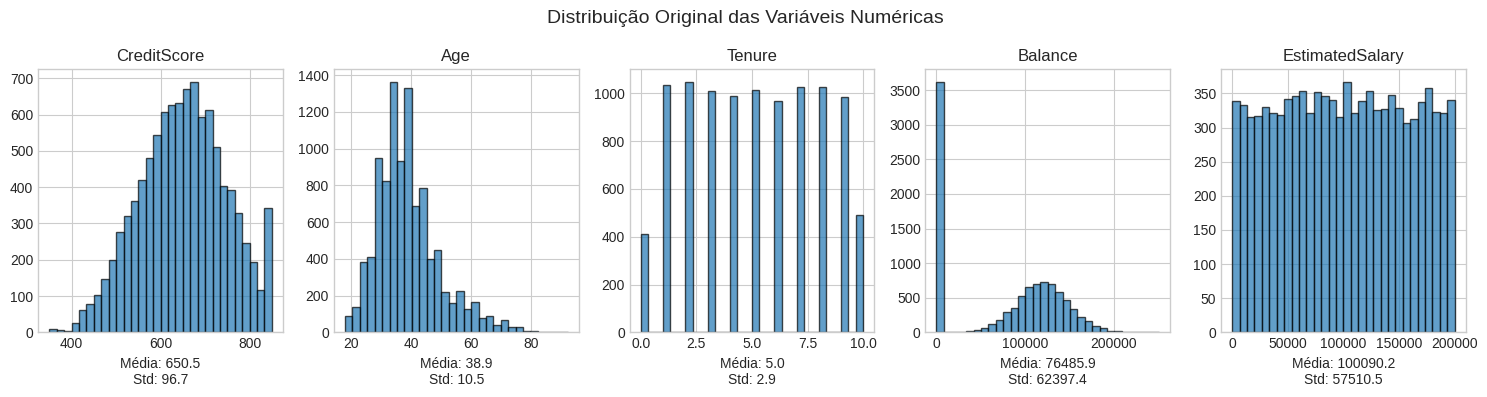


Observe as diferentes escalas:
      CreditScore     Age  Tenure     Balance  EstimatedSalary
mean     650.5288 38.9218  5.0128  76485.8893      100090.2399
std       96.6533 10.4878  2.8922  62397.4052       57510.4928
min      350.0000 18.0000  0.0000      0.0000          11.5800
max      850.0000 92.0000 10.0000 250898.0900      199992.4800


In [39]:
# Visualização das escalas originais
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 4))
fig.suptitle('Distribuição Original das Variáveis Numéricas', fontsize=14)

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(f'Média: {df[col].mean():.1f}\nStd: {df[col].std():.1f}')

plt.tight_layout()
plt.show()

print("\nObserve as diferentes escalas:")
print(df[numeric_cols].describe().loc[['mean', 'std', 'min', 'max']])

---

## 2. MinMaxScaler (Normalização Min-Max)

### Fórmula:
$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Para um range específico [a, b]:
$$x_{scaled} = a + \frac{(x - x_{min})(b - a)}{x_{max} - x_{min}}$$

### Características:
- **Resultado padrão:** valores entre [0, 1]
- **Range configurável:** pode ser [0, 1], [-1, 1], etc.
- **MUITO sensível a outliers:** um único outlier comprime todos os outros valores

### Quando usar:
- Quando precisa de valores em um range fixo (ex: pixels de imagem [0, 255] → [0, 1])
- Algoritmos que requerem valores positivos
- Dados SEM outliers significativos

---

## 1. StandardScaler (Padronização / Z-Score)

### Fórmula:
$$z = \frac{x - \mu}{\sigma}$$

Onde:
- $x$ = valor original
- $\mu$ = média da feature
- $\sigma$ = desvio padrão da feature

### Características:
- **Resultado:** média = 0, desvio padrão = 1
- **Range:** não limitado (pode ter valores < -1 ou > 1)
- **Sensível a outliers:** sim (outliers afetam média e desvio padrão)

### Quando usar:
- Dados aproximadamente normais (gaussianos)
- Algoritmos que assumem distribuição normal
- SVM, Regressão Logística, Redes Neurais

In [42]:
# Demonstração manual do StandardScaler
col_demo = 'Age'

mean_age = df[col_demo].mean()
std_age = df[col_demo].std()

print(f"=== Demonstração Manual do StandardScaler para '{col_demo}' ===")
print(f"\nMédia original: {mean_age:.4f}")
print(f"Desvio padrão original: {std_age:.4f}")

# Cálculo manual
age_standardized_manual = (df[col_demo] - mean_age) / std_age

print(f"\nApós padronização:")
print(f"Média: {age_standardized_manual.mean():.10f} (esperado: 0)")
print(f"Desvio padrão: {age_standardized_manual.std():.10f} (esperado: 1)")

=== Demonstração Manual do StandardScaler para 'Age' ===

Média original: 38.9218
Desvio padrão original: 10.4878

Após padronização:
Média: 0.0000000000 (esperado: 0)
Desvio padrão: 1.0000000000 (esperado: 1)


In [43]:
# Usando sklearn StandardScaler
scaler_standard = StandardScaler()

# IMPORTANTE: fit apenas nos dados de treino!
# Para demonstração, usamos todo o dataset
df_standard = df[numeric_cols].copy()
df_standard_scaled = pd.DataFrame(
    scaler_standard.fit_transform(df_standard),
    columns=[f"{col}_std" for col in numeric_cols]
)

print("Estatísticas após StandardScaler:")
print(df_standard_scaled.describe().loc[['mean', 'std', 'min', 'max']])

Estatísticas após StandardScaler:
      CreditScore_std  Age_std  Tenure_std  Balance_std  EstimatedSalary_std
mean          -0.0000   0.0000     -0.0000      -0.0000              -0.0000
std            1.0001   1.0001      1.0001       1.0001               1.0001
min           -3.1095  -1.9950     -1.7333      -1.2258              -1.7403
max            2.0639   5.0612      1.7245       2.7953               1.7372


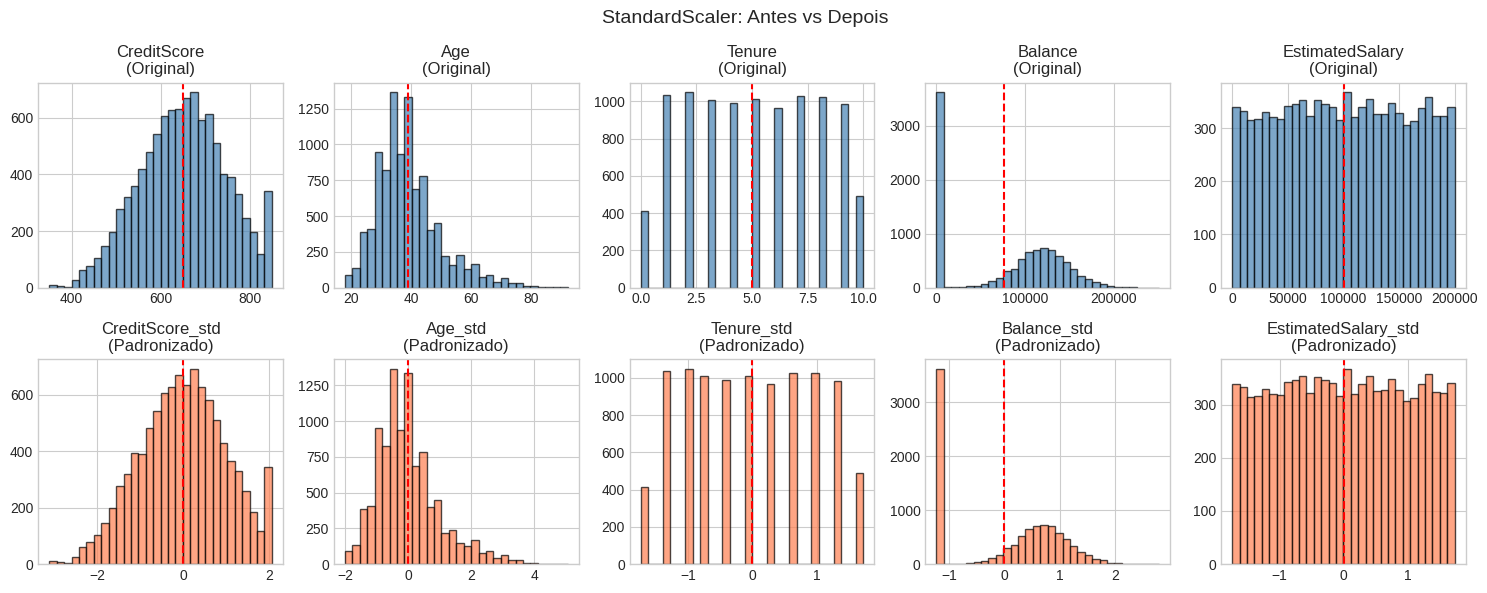

In [44]:
# Visualização do efeito do StandardScaler
fig, axes = plt.subplots(2, len(numeric_cols), figsize=(15, 6))
fig.suptitle('StandardScaler: Antes vs Depois', fontsize=14)

for i, col in enumerate(numeric_cols):
    # Original
    axes[0, i].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, i].set_title(f'{col}\n(Original)')
    axes[0, i].axvline(df[col].mean(), color='red', linestyle='--', label='média')

    # Padronizado
    axes[1, i].hist(df_standard_scaled[f'{col}_std'], bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[1, i].set_title(f'{col}_std\n(Padronizado)')
    axes[1, i].axvline(0, color='red', linestyle='--', label='média=0')

plt.tight_layout()
plt.show()

In [45]:
# Demonstração manual do MinMaxScaler
col_demo = 'Balance'

min_val = df[col_demo].min()
max_val = df[col_demo].max()

print(f"=== Demonstração Manual do MinMaxScaler para '{col_demo}' ===")
print(f"\nValor mínimo: {min_val:.4f}")
print(f"Valor máximo: {max_val:.4f}")

# Cálculo manual
balance_minmax_manual = (df[col_demo] - min_val) / (max_val - min_val)

print(f"\nApós normalização:")
print(f"Min: {balance_minmax_manual.min():.4f} (esperado: 0)")
print(f"Max: {balance_minmax_manual.max():.4f} (esperado: 1)")

=== Demonstração Manual do MinMaxScaler para 'Balance' ===

Valor mínimo: 0.0000
Valor máximo: 250898.0900

Após normalização:
Min: 0.0000 (esperado: 0)
Max: 1.0000 (esperado: 1)


In [46]:
# Usando sklearn MinMaxScaler
scaler_minmax = MinMaxScaler()  # padrão: feature_range=(0, 1)

df_minmax_scaled = pd.DataFrame(
    scaler_minmax.fit_transform(df[numeric_cols]),
    columns=[f"{col}_mm" for col in numeric_cols]
)

print("Estatísticas após MinMaxScaler:")
print(df_minmax_scaled.describe().loc[['mean', 'std', 'min', 'max']])

Estatísticas após MinMaxScaler:
      CreditScore_mm  Age_mm  Tenure_mm  Balance_mm  EstimatedSalary_mm
mean          0.6011  0.2827     0.5013      0.3048              0.5004
std           0.1933  0.1417     0.2892      0.2487              0.2876
min           0.0000  0.0000     0.0000      0.0000              0.0000
max           1.0000  1.0000     1.0000      1.0000              1.0000


In [47]:
# Demonstrando o problema com outliers
print("=== Problema do MinMaxScaler com Outliers ===")

# Criando dados de exemplo com outlier
dados_normais = np.array([10, 12, 11, 13, 12, 14, 11, 13]).reshape(-1, 1)
dados_com_outlier = np.array([10, 12, 11, 13, 12, 14, 11, 1000]).reshape(-1, 1)  # 1000 é outlier

scaler = MinMaxScaler()

print("\nDados normais:")
print(f"Original: {dados_normais.flatten()}")
print(f"Normalizado: {scaler.fit_transform(dados_normais).flatten().round(3)}")

print("\nDados COM outlier (1000):")
print(f"Original: {dados_com_outlier.flatten()}")
print(f"Normalizado: {scaler.fit_transform(dados_com_outlier).flatten().round(4)}")
print("\n⚠️ OBSERVE: O outlier 'comprimiu' todos os valores normais próximos a 0!")

=== Problema do MinMaxScaler com Outliers ===

Dados normais:
Original: [10 12 11 13 12 14 11 13]
Normalizado: [0.   0.5  0.25 0.75 0.5  1.   0.25 0.75]

Dados COM outlier (1000):
Original: [  10   12   11   13   12   14   11 1000]
Normalizado: [0.    0.002 0.001 0.003 0.002 0.004 0.001 1.   ]

⚠️ OBSERVE: O outlier 'comprimiu' todos os valores normais próximos a 0!


---

## 3. RobustScaler (Escalonamento Robusto)

### Fórmula:
$$x_{robust} = \frac{x - Q_2}{Q_3 - Q_1}$$

Onde:
- $Q_1$ = 1º quartil (percentil 25)
- $Q_2$ = 2º quartil (mediana, percentil 50)
- $Q_3$ = 3º quartil (percentil 75)
- $IQR = Q_3 - Q_1$ (Intervalo Interquartil)

### Características:
- **Centro:** mediana (não média)
- **Escala:** IQR (não desvio padrão)
- **Robusto a outliers:** outliers não afetam mediana e IQR significativamente
- **Range:** não limitado

### Quando usar:
- Dados com outliers significativos
- Distribuições assimétricas (skewed)
- Quando não pode/quer remover outliers

In [40]:
# Demonstração manual do RobustScaler
col_demo = 'Balance'

q1 = df[col_demo].quantile(0.25)
q2 = df[col_demo].quantile(0.50)  # mediana
q3 = df[col_demo].quantile(0.75)
iqr = q3 - q1

print(f"=== Demonstração Manual do RobustScaler para '{col_demo}' ===")
print(f"\nQ1 (25%): {q1:.4f}")
print(f"Q2 (mediana): {q2:.4f}")
print(f"Q3 (75%): {q3:.4f}")
print(f"IQR: {iqr:.4f}")

# Cálculo manual
balance_robust_manual = (df[col_demo] - q2) / iqr

print(f"\nApós escalonamento robusto:")
print(f"Mediana: {balance_robust_manual.median():.10f} (esperado: 0)")

=== Demonstração Manual do RobustScaler para 'Balance' ===

Q1 (25%): 0.0000
Q2 (mediana): 97198.5400
Q3 (75%): 127644.2400
IQR: 127644.2400

Após escalonamento robusto:
Mediana: -0.0000000000 (esperado: 0)


In [41]:
# Usando sklearn RobustScaler
scaler_robust = RobustScaler()

df_robust_scaled = pd.DataFrame(
    scaler_robust.fit_transform(df[numeric_cols]),
    columns=[f"{col}_rob" for col in numeric_cols]
)

print("Estatísticas após RobustScaler:")
print(df_robust_scaled.describe().loc[['mean', 'std', 'min', 'max', '25%', '50%', '75%']])

Estatísticas após RobustScaler:
      CreditScore_rob  Age_rob  Tenure_rob  Balance_rob  EstimatedSalary_rob
mean          -0.0110   0.1601      0.0032      -0.1623              -0.0011
std            0.7213   0.8740      0.7230       0.4888               0.5845
min           -2.2537  -1.5833     -1.2500      -0.7615              -1.0183
max            1.4776   4.5833      1.2500       1.2041               1.0144
25%           -0.5075  -0.4167     -0.5000      -0.7615              -0.5000
50%            0.0000   0.0000      0.0000      -0.0000               0.0000
75%            0.4925   0.5833      0.5000       0.2385               0.5000


In [37]:
# Comparação: RobustScaler vs MinMaxScaler com outliers
print("=== Comparação: RobustScaler vs MinMaxScaler com Outliers ===")

dados_com_outlier = np.array([10, 12, 11, 13, 12, 14, 11, 1000]).reshape(-1, 1)

scaler_mm = MinMaxScaler()
scaler_rob = RobustScaler()

print(f"\nDados originais: {dados_com_outlier.flatten()}")
print(f"\nMinMaxScaler: {scaler_mm.fit_transform(dados_com_outlier).flatten().round(4)}")
print(f"RobustScaler: {scaler_rob.fit_transform(dados_com_outlier).flatten().round(4)}")

print("\n✅ OBSERVE: RobustScaler preserva melhor a variabilidade dos dados normais!")

=== Comparação: RobustScaler vs MinMaxScaler com Outliers ===

Dados originais: [  10   12   11   13   12   14   11 1000]

MinMaxScaler: [0.    0.002 0.001 0.003 0.002 0.004 0.001 1.   ]
RobustScaler: [ -0.8889   0.      -0.4444   0.4444   0.       0.8889  -0.4444 439.1111]

✅ OBSERVE: RobustScaler preserva melhor a variabilidade dos dados normais!


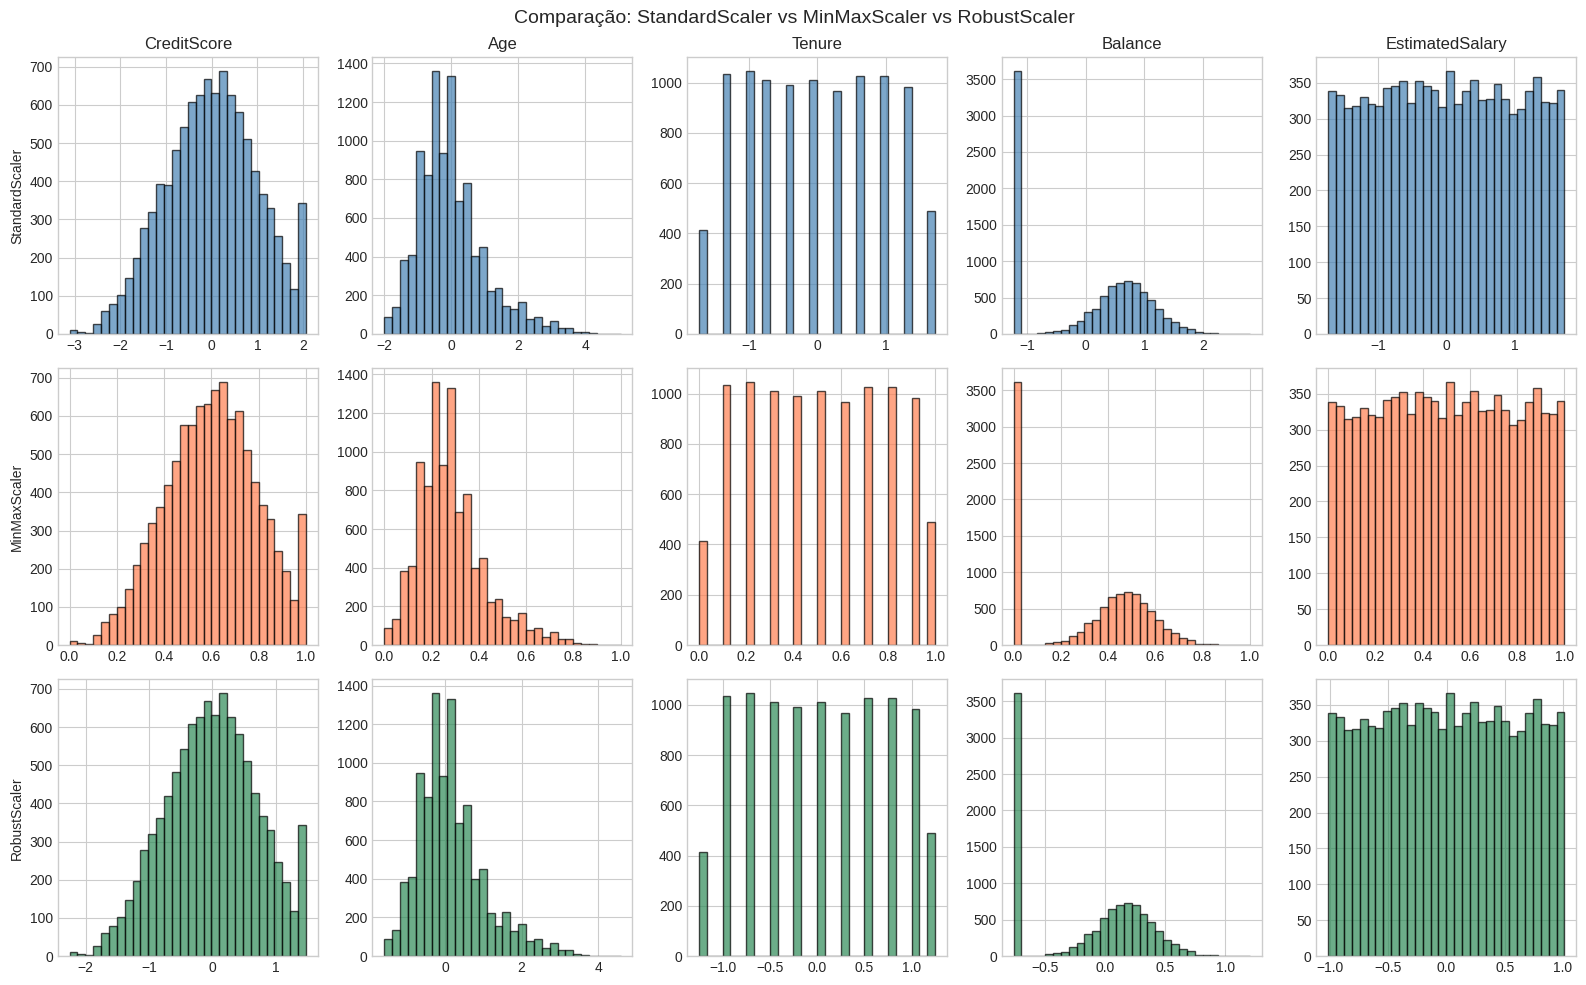

In [48]:
# Visualização comparativa dos três scalers
fig, axes = plt.subplots(3, len(numeric_cols), figsize=(16, 10))
fig.suptitle('Comparação: StandardScaler vs MinMaxScaler vs RobustScaler', fontsize=14)

scalers_data = [
    (df_standard_scaled, 'StandardScaler', 'steelblue'),
    (df_minmax_scaled, 'MinMaxScaler', 'coral'),
    (df_robust_scaled, 'RobustScaler', 'seagreen')
]

for row, (data, name, color) in enumerate(scalers_data):
    for col_idx, col in enumerate(numeric_cols):
        col_scaled = data.columns[col_idx]
        axes[row, col_idx].hist(data[col_scaled], bins=30, edgecolor='black', alpha=0.7, color=color)
        if col_idx == 0:
            axes[row, col_idx].set_ylabel(name)
        if row == 0:
            axes[row, col_idx].set_title(col)

plt.tight_layout()
plt.show()

### Resumo: Quando usar cada Scaler

| Scaler | Quando Usar | Sensível a Outliers | Range |
|--------|-------------|---------------------|-------|
| **StandardScaler** | Dados ~normais, SVM, Regressão, NN | Sim | Não limitado |
| **MinMaxScaler** | Dados sem outliers, range fixo necessário | Muito | [0, 1] |
| **RobustScaler** | Dados com outliers, distribuições assimétricas | Não | Não limitado |

---

---

# PARTE 3: TARGET LEAKAGE (VAZAMENTO DO TARGET)

## ⚠️ CONCEITO CRÍTICO - DEVE SER EVITADO!

### O que é Target Leakage?

Target Leakage ocorre quando **informação do target "vaza" para as features de treino**, resultando em:
- Métricas de validação artificialmente altas
- Performance terrível em produção
- Modelo que não generaliza

### Tipos de Target Leakage:

1. **Train-Test Contamination:** usar informação do teste para processar treino
2. **Feature Leakage:** features que contêm informação do target
3. **Temporal Leakage:** usar dados futuros para prever o passado

---

## 9.1 Target Leakage em Escalonamento

### ERRADO:
```python
# Fit no dataset completo ANTES do split
scaler.fit(X)  # ❌ Usa estatísticas do teste!
X_scaled = scaler.transform(X)
X_train, X_test = train_test_split(X_scaled)
```

### CORRETO:
```python
# Split PRIMEIRO, depois fit apenas no treino
X_train, X_test = train_test_split(X)
scaler.fit(X_train)  # ✅ Apenas dados de treino
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Usa parâmetros do treino
```

In [49]:
# Demonstração: Escalonamento CORRETO vs ERRADO
print("=== Demonstração: Escalonamento Correto vs Errado ===")

# Preparando dados
X = df[numeric_cols].values
y = df[target].values

# MÉTODO ERRADO: fit antes do split
print("\n❌ MÉTODO ERRADO (fit antes do split):")
scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X)  # Usa TODO o dataset!
X_train_wrong, X_test_wrong, y_train, y_test = train_test_split(
    X_scaled_wrong, y, test_size=0.2, random_state=42
)
print(f"   Média do scaler: {scaler_wrong.mean_[:3]}")
print(f"   (Calculada usando treino + teste)")

# MÉTODO CORRETO: fit depois do split, apenas no treino
print("\n✅ MÉTODO CORRETO (fit apenas no treino):")
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler_correct = StandardScaler()
X_train_correct = scaler_correct.fit_transform(X_train_raw)  # Fit apenas no treino
X_test_correct = scaler_correct.transform(X_test_raw)  # Transform com parâmetros do treino
print(f"   Média do scaler: {scaler_correct.mean_[:3]}")
print(f"   (Calculada usando APENAS treino)")

=== Demonstração: Escalonamento Correto vs Errado ===

❌ MÉTODO ERRADO (fit antes do split):
   Média do scaler: [650.5288  38.9218   5.0128]
   (Calculada usando treino + teste)

✅ MÉTODO CORRETO (fit apenas no treino):
   Média do scaler: [651.647625  38.89775    5.003875]
   (Calculada usando APENAS treino)


## 9.2 Target Leakage em Target Encoding

Este é o caso mais perigoso e comum de target leakage.

### PROBLEMA:
Se calculamos a média do target por categoria usando TODO o dataset (incluindo a própria observação), estamos vazando informação do target para as features.

### EXEMPLO:
Imagine uma categoria rara com apenas 1 observação onde Exited=1.
- Target encoding ingênuo: essa categoria recebe valor 1.0
- O modelo aprende: "se target_encoded=1.0, então Exited=1"
- Isso é **trapaça**, não aprendizado!

### SOLUÇÕES:
1. **Leave-One-Out (LOO):** Calcula média excluindo a própria observação
2. **K-Fold Target Encoding:** Usa validação cruzada para calcular encoding
3. **Smoothing:** Adiciona regularização

In [50]:
# Demonstração DRAMÁTICA de Target Leakage
print("=== Demonstração de Target Leakage com Target Encoding ===")

# Criar cópia do dataframe
df_leak = df.copy()

# TARGET ENCODING INGÊNUO (COM LEAKAGE)
print("\n❌ TARGET ENCODING INGÊNUO (com leakage):")
for col in categorical_cols:
    target_mean = df_leak.groupby(col)[target].mean()
    df_leak[f'{col}_leak'] = df_leak[col].map(target_mean)

# Preparar features com leakage
features_leak = [f'{col}_leak' for col in categorical_cols]
X_leak = df_leak[features_leak].values
y = df_leak[target].values

# Split
X_train_leak, X_test_leak, y_train, y_test = train_test_split(
    X_leak, y, test_size=0.2, random_state=42
)

# Treinar modelo
model_leak = LogisticRegression(random_state=42, max_iter=1000)
model_leak.fit(X_train_leak, y_train)

# Avaliar
train_score_leak = model_leak.score(X_train_leak, y_train)
test_score_leak = model_leak.score(X_test_leak, y_test)

print(f"   Acurácia Treino: {train_score_leak:.4f}")
print(f"   Acurácia Teste:  {test_score_leak:.4f}")

=== Demonstração de Target Leakage com Target Encoding ===

❌ TARGET ENCODING INGÊNUO (com leakage):
   Acurácia Treino: 0.7945
   Acurácia Teste:  0.8035


In [51]:
# TARGET ENCODING CORRETO (sem leakage)
print("\n✅ TARGET ENCODING CORRETO (sem leakage):")

# Split PRIMEIRO
df_train, df_test = train_test_split(df.copy(), test_size=0.2, random_state=42)

# Calcular encoding APENAS no treino
for col in categorical_cols:
    # Média calculada APENAS no treino
    target_mean_train = df_train.groupby(col)[target].mean()

    # Aplicar no treino e teste
    df_train[f'{col}_target'] = df_train[col].map(target_mean_train)
    df_test[f'{col}_target'] = df_test[col].map(target_mean_train)

    # Tratar categorias desconhecidas no teste (preencher com média global do treino)
    global_mean = df_train[target].mean()
    df_test[f'{col}_target'].fillna(global_mean, inplace=True)

# Preparar features
features_correct = [f'{col}_target' for col in categorical_cols]
X_train_correct = df_train[features_correct].values
X_test_correct = df_test[features_correct].values
y_train = df_train[target].values
y_test = df_test[target].values

# Treinar modelo
model_correct = LogisticRegression(random_state=42, max_iter=1000)
model_correct.fit(X_train_correct, y_train)

# Avaliar
train_score_correct = model_correct.score(X_train_correct, y_train)
test_score_correct = model_correct.score(X_test_correct, y_test)

print(f"   Acurácia Treino: {train_score_correct:.4f}")
print(f"   Acurácia Teste:  {test_score_correct:.4f}")


✅ TARGET ENCODING CORRETO (sem leakage):
   Acurácia Treino: 0.7945
   Acurácia Teste:  0.8035


In [52]:
# Comparação final
print("\n" + "="*60)
print("COMPARAÇÃO FINAL: Target Leakage vs Correto")
print("="*60)

print(f"\n{'Método':<35} {'Treino':>10} {'Teste':>10} {'Diferença':>12}")
print("-"*60)
print(f"{'❌ Com Target Leakage':<35} {train_score_leak:>10.4f} {test_score_leak:>10.4f} {train_score_leak-test_score_leak:>12.4f}")
print(f"{'✅ Correto (sem leakage)':<35} {train_score_correct:>10.4f} {test_score_correct:>10.4f} {train_score_correct-test_score_correct:>12.4f}")

print("""
\n📊 INTERPRETAÇÃO:
- O método COM leakage mostra performance similar no treino e teste
  porque a informação do target já está codificada nas features.

- Em dados NOVOS (produção), o método com leakage falhará porque
  não terá acesso ao target para calcular o encoding.

- O método CORRETO pode ter performance aparentemente menor,
  mas representa a performance REAL esperada em produção.
""")


COMPARAÇÃO FINAL: Target Leakage vs Correto

Método                                  Treino      Teste    Diferença
------------------------------------------------------------
❌ Com Target Leakage                    0.7945     0.8035      -0.0090
✅ Correto (sem leakage)                 0.7945     0.8035      -0.0090


📊 INTERPRETAÇÃO:
- O método COM leakage mostra performance similar no treino e teste
  porque a informação do target já está codificada nas features.

- Em dados NOVOS (produção), o método com leakage falhará porque
  não terá acesso ao target para calcular o encoding.

- O método CORRETO pode ter performance aparentemente menor,
  mas representa a performance REAL esperada em produção.



In [53]:
# K-Fold Target Encoding (método mais robusto)
from sklearn.model_selection import KFold

print("=== K-Fold Target Encoding (Método Robusto) ===")

def kfold_target_encode(df, col, target, n_splits=5, smooth_m=10):
    """
    Target encoding usando K-Fold para evitar leakage.

    Para cada fold:
    - Calcula a média do target nos outros (K-1) folds
    - Aplica essa média ao fold atual

    Isso garante que nenhuma observação use sua própria informação.
    """
    df = df.copy()
    df['target_encoded'] = np.nan

    global_mean = df[target].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(df):
        # Calcular médias usando apenas os dados de "treino" do fold
        train_data = df.iloc[train_idx]
        agg = train_data.groupby(col)[target].agg(['mean', 'count'])

        # Smoothing
        smooth_mean = (agg['count'] * agg['mean'] + smooth_m * global_mean) / (agg['count'] + smooth_m)
        encoding_map = smooth_mean.to_dict()

        # Aplicar ao fold de validação
        df.loc[val_idx, 'target_encoded'] = df.loc[val_idx, col].map(encoding_map)

    # Preencher NaN com média global
    df['target_encoded'].fillna(global_mean, inplace=True)

    return df['target_encoded'].values

# Aplicar K-Fold Target Encoding
df_kfold = df.copy()
for col in categorical_cols:
    df_kfold[f'{col}_kfold'] = kfold_target_encode(df_kfold, col, target, n_splits=5)

print("\nK-Fold Target Encoding aplicado!")
print("Cada observação foi codificada usando apenas informação de OUTROS folds.")
df_kfold[categorical_cols + [f'{col}_kfold' for col in categorical_cols] + [target]].head(10)

=== K-Fold Target Encoding (Método Robusto) ===

K-Fold Target Encoding aplicado!
Cada observação foi codificada usando apenas informação de OUTROS folds.


,Geography,Gender,Geography_kfold,Gender_kfold,Exited
0,France,Female,0.1626,0.2525,1
1,Spain,Female,0.1653,0.2495,0
2,France,Female,0.1595,0.2523,1
3,France,Female,0.1626,0.2525,0
4,Spain,Female,0.1653,0.2495,0
5,Spain,Male,0.1653,0.1645,1
6,France,Male,0.1632,0.1665,0
7,Germany,Female,0.3260,0.2506,1
8,France,Male,0.1626,0.1663,0
9,France,Male,0.1619,0.1645,0


---

## Resumo: Prevenção de Target Leakage

### ⚠️ REGRAS DE OURO:

1. **SEMPRE faça o split PRIMEIRO** antes de qualquer transformação

2. **Fit apenas no treino:** `scaler.fit(X_train)`, nunca `fit(X)`

3. **Target Encoding:** Use K-Fold ou Leave-One-Out, NUNCA encoding ingênuo

4. **Use Pipelines:** sklearn Pipelines garantem que transformações são aplicadas corretamente

5. **Validação cruzada:** Use `cross_val_score` para detectar leakage (se treino >> teste, há leakage)

6. **Features suspeitas:** Questione features com correlação muito alta com target

7. **Dados temporais:** Nunca use dados futuros para prever passado

---

In [54]:
# Pipeline correto usando sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("=== Exemplo de Pipeline Correto ===")

# Definir transformações
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combinar transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Pipeline completo com modelo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Preparar dados
X = df[numeric_cols + categorical_cols]
y = df[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# O Pipeline garante que fit é apenas no treino!
pipeline.fit(X_train, y_train)

# Avaliar
train_score = pipeline.score(X_train, y_train)
test_score = pipeline.score(X_test, y_test)

print(f"\nPipeline com transformações corretas:")
print(f"  Acurácia Treino: {train_score:.4f}")
print(f"  Acurácia Teste:  {test_score:.4f}")

# Cross-validation para validação mais robusta
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f"\nCross-Validation (5-fold):")
print(f"  Scores: {cv_scores.round(4)}")
print(f"  Média: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

=== Exemplo de Pipeline Correto ===

Pipeline com transformações corretas:
  Acurácia Treino: 0.7894
  Acurácia Teste:  0.7995

Cross-Validation (5-fold):
  Scores: [0.7945 0.7855 0.7945 0.7915 0.7905]
  Média: 0.7913 (+/- 0.0066)


---

# Resumo Final

## Escalonamento de Variáveis Numéricas

| Técnica | Fórmula | Quando Usar | Sensível a Outliers |
|---------|---------|-------------|---------------------|
| **StandardScaler** | $(x - \mu) / \sigma$ | Dados ~normais, SVM, NN | Sim |
| **MinMaxScaler** | $(x - min) / (max - min)$ | Range fixo, sem outliers | Muito |
| **RobustScaler** | $(x - mediana) / IQR$ | Dados com outliers | Não |

## Codificação de Variáveis Categóricas

| Técnica | Quando Usar | Aumenta Dim? | Cuidados |
|---------|-------------|--------------|----------|
| **Label Encoding** | Variáveis ordinais, árvores | Não | Impõe ordem |
| **One-Hot Encoding** | Variáveis nominais, baixa cardinalidade | Sim | Dummy trap |
| **Frequency Encoding** | Alta cardinalidade | Não | Mesma freq = mesmo valor |
| **Rare Label Encoding** | Categorias raras | Depende | Escolha do threshold |
| **Target Encoding** | Alta cardinalidade, relação com target | Não | **TARGET LEAKAGE!** |

## Target Leakage - EVITAR!

1. **Split primeiro, transforme depois**
2. **Fit apenas no treino**
3. **Use K-Fold para Target Encoding**
4. **Pipelines são seus amigos**

---

In [55]:
print("\n" + "="*60)
print("FIM DO NOTEBOOK - Técnicas de Pré-processamento")
print("="*60)
print("""
📚 Conceitos abordados:
   1. StandardScaler (z-score)
   2. MinMaxScaler (normalização 0-1)
   3. RobustScaler (robusto a outliers)
   4. Label Encoding (ordinal)
   5. One-Hot Encoding (dummy variables)
   6. Count/Frequency Encoding
   7. Rare Label Encoding
   8. Target Encoding (com smoothing e K-Fold)
   9. Target Leakage (o que é e como evitar)

🎯 Lembre-se:
   - A escolha da técnica depende do algoritmo e dos dados
   - SEMPRE faça split antes de transformar
   - Pipelines garantem reprodutibilidade e evitam leakage
""")


FIM DO NOTEBOOK - Técnicas de Pré-processamento

📚 Conceitos abordados:
   1. StandardScaler (z-score)
   2. MinMaxScaler (normalização 0-1)
   3. RobustScaler (robusto a outliers)
   4. Label Encoding (ordinal)
   5. One-Hot Encoding (dummy variables)
   6. Count/Frequency Encoding
   7. Rare Label Encoding
   8. Target Encoding (com smoothing e K-Fold)
   9. Target Leakage (o que é e como evitar)

🎯 Lembre-se:
   - A escolha da técnica depende do algoritmo e dos dados
   - SEMPRE faça split antes de transformar
   - Pipelines garantem reprodutibilidade e evitam leakage

